In [287]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv; load_dotenv()

# Hyperparamyters
BASE_PATH = os.getenv("BASE_PATH_FOR_SAVING")
DISEASE_TYPE = "diseased" # diseased / healthy
SAMPLE_ID = "sample_01"
BCL = "251027_SL-EXD_0706_A233KGFLT4" # 251027_SL-EXD_0706_A233KGFLT4 260313_SL-EXA_0758_B23GHNHLT4 
LIBRARY = "SI-TT-H1"

In [288]:
os.path.join(BASE_PATH, DISEASE_TYPE, SAMPLE_ID, BCL, LIBRARY, "slide_tags")

'/home/gdallagl/myworkdir/data/XDP/diseased/sample_01/251027_SL-EXD_0706_A233KGFLT4/SI-TT-H1/slide_tags'

# 0. From BCL to Count Matrix

After sequencing, you must have run
1) all pipeline to get count matrix --> cellranger, slidetags postioning, ...
2) run cellbender to remove ambient rna [https://docs.google.com/document/d/1EbpN-GFM6xzYTmJRzb6d-8zTW8PVqgiJVurP5kREU7s/edit?tab=t.0]


*) copy from Terra bucket to macoko bucket: 
`gsutil cp "gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/slide-tags/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-B10/summary.pdf" "gs://macosko_data/gdallagl/XDP/second_3_xdp_samples/SI-TT-B10/summary.pdf"`

# 1. Make raw adata object
## 1.1 Copy data from Google Bucket (Terra) to here

In [289]:
# slide tags counts
!gsutil cp gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/slide-tags/{BCL}/{LIBRARY}/seurat.qs {os.path.join(BASE_PATH, DISEASE_TYPE, SAMPLE_ID, BCL, LIBRARY, "slide_tags")}

# cell bender counts
!gsutil cp gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/gene-expression/{BCL}/{LIBRARY}/cellbender/{LIBRARY}/{LIBRARY}_out_filtered.h5 {os.path.join(BASE_PATH, DISEASE_TYPE, SAMPLE_ID, BCL, LIBRARY, "cellbender")}

# dropsift qc metrics
!gsutil cp gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/gene-expression/{BCL}/{LIBRARY}/dropsift_outputs/dropsift_output.csv {os.path.join(BASE_PATH, DISEASE_TYPE, SAMPLE_ID, BCL, LIBRARY, "dropsift")}



Copying gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/slide-tags/251027_SL-EXD_0706_A233KGFLT4/SI-TT-H1/seurat.qs...
| [1 files][846.1 MiB/846.1 MiB]   76.5 MiB/s                                   
Operation completed over 1 objects/846.1 MiB.                                    
Copying gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/gene-expression/251027_SL-EXD_0706_A233KGFLT4/SI-TT-H1/cellbender/SI-TT-H1/SI-TT-H1_out_filtered.h5...
| [1 files][165.6 MiB/165.6 MiB]                                                
Operation completed over 1 objects/165.6 MiB.                                    
Copying gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/gene-expression/251027_SL-EXD_0706_A233KGFLT4/SI-TT-H1/dropsift_outputs/dropsift_output.csv...
/ [1 files][ 22.1 MiB/ 22.1 MiB]                                                
Operation completed over 1 objects/22.1 MiB.                                     


## 1.2 Install: R dependecies, R, qs library
Needed to convert .qs file into h5ad
- Install R dependencies
```bash
sudo apt-get install -y \
    build-essential \
    libhdf5-dev \
    libzstd-dev \
    liblz4-dev \
    libxxhash-dev \
    libcurl4-openssl-dev \
    libssl-dev \
    libxml2-dev \
    zlib1g-dev
```

- Install R
```bash
sudo apt-get install r-base r-base-dev
 ```

- install qs library
 ```R
install.packages("qs")
 ```

# 2. Extract metadata (x,y) from slidetags .qs file

In [290]:
cwd = os.getcwd()
print(cwd)
slide_tags_folder = f"{BASE_PATH}/{DISEASE_TYPE}/{SAMPLE_ID}/{BCL}/{LIBRARY}/slide_tags/"

%cd {slide_tags_folder}

/home/gdallagl/myworkdir/XDP/script/single_sample_analysis-Slide_tag
/home/gdallagl/myworkdir/data/XDP/diseased/sample_01/251027_SL-EXD_0706_A233KGFLT4/SI-TT-H1/slide_tags


In [291]:
%%bash
R --vanilla << 'EOF'
library(qs)

# Read the Seurat object
seurat <- qread("./seurat.qs")

# Extract and save just the metadata
metadata <- seurat@meta.data
write.csv(metadata, "./seurat_metadata.csv", row.names = TRUE)

bash: line 9: warning: here-document at line 1 delimited by end-of-file (wanted `EOF')



R version 4.5.2 (2025-10-31) -- "[Not] Part in a Rumble"
Copyright (C) 2025 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> library(qs)


qs 0.27.3. Announcement: https://github.com/qsbase/qs/issues/103


> 
> # Read the Seurat object
> seurat <- qread("./seurat.qs")
> 
> # Extract and save just the metadata
> metadata <- seurat@meta.data
> write.csv(metadata, "./seurat_metadata.csv", row.names = TRUE)
> 


In [292]:
%cd {cwd}

/home/gdallagl/myworkdir/XDP/script/single_sample_analysis-Slide_tag


# Read DropSift Qc metrics

In [293]:
df_dropsift = pd.read_csv(f"{BASE_PATH}/{DISEASE_TYPE}/{SAMPLE_ID}/{BCL}/{LIBRARY}/dropsift/dropsift_output.csv")
df_dropsift.rename(columns={"is_cell": "is_cell_dropsift"}, inplace=True)
df_dropsift.head()

,cell_barcode,num_transcripts,pct_intronic,pct_mt,frac_contamination,num_retained_transcripts,training_label_is_cell,empty_gene_module_score,is_cell_dropsift,is_cell_prob
0,AAACCAAAGACAGCCT-1,359,0.247911,0.013928,1.0,0,False,0.228584,False,NaN
1,AAACCAAAGACATGAA-1,331,0.232628,0.012085,1.0,0,False,0.060262,False,NaN
2,AAACCAAAGAGCCTGT-1,406,0.209360,0.029557,1.0,0,NaN,0.176456,False,0.00002
3,AAACCAAAGAGCGGAC-1,254,0.185039,0.019685,1.0,0,NaN,0.280875,False,NaN
4,AAACCAAAGAGTTTAC-1,227,0.189427,0.030837,1.0,0,NaN,0.187350,False,NaN


# Read metadat Slidetag

In [294]:
metadata_slidetags = pd.read_csv(f"{BASE_PATH}/{DISEASE_TYPE}/{SAMPLE_ID}/{BCL}/{LIBRARY}/slide_tags/seurat_metadata.csv").rename(columns={"Unnamed: 0": "barcode"})
metadata_slidetags.rename(columns={"is_cell": "is_cell_slidetag", "barcode": "cell_barcode"}, inplace=True)
display(metadata_slidetags.head())

,cell_barcode,orig.ident,nCount_RNA,nFeature_RNA,is_cell_slidetag,pct_intronic,pct_mt,RNA_snn_res.0.8,seurat_clusters,x,y,dbscan_clusters,dbscan_score
0,AAACCAAAGATAACAG-1,Slide-tags,7703,3727,True,0.585746,0.004284,3,3,33013.428400,444.562211,3,0.230731
1,AAACCAAAGCATGGAG-1,Slide-tags,4864,2453,True,0.596834,0.002056,4,4,21225.159553,4193.340108,1,0.942997
2,AAACCAAAGGCGGAGT-1,Slide-tags,6819,2594,True,0.716821,0.000440,11,11,16429.015488,3852.143369,1,0.936590
3,AAACCAAAGGTCTATG-1,Slide-tags,2507,1372,True,0.609493,0.001994,3,3,43242.438818,-1822.457007,0,0.366933
4,AAACCAAAGGTTGTAT-1,Slide-tags,4757,2020,True,0.588186,0.002312,0,0,14118.369028,-4852.270550,1,0.859807


# Read Count matrix from CellBender

In [295]:
# 1. Load CellBender cleaned counts
adata_cb = sc.read_10x_h5(f"{BASE_PATH}/{DISEASE_TYPE}/{SAMPLE_ID}/{BCL}/{LIBRARY}/cellbender/{LIBRARY}_out_filtered.h5")
print(adata_cb)
adata_cb.obs

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 34907 × 38606
    var: 'gene_ids', 'feature_types', 'genome'


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


""
AGCGACAAGGTAAGGT-1
GGTCTGTAGCAATCCA-1
GGGTTACTCGCACCTC-1
GGCGTAAAGCCTTTAC-1
GTCAACATCGCGTCAG-1
...
ACGTCCACACAAGCCC-1
GTGCATATCCGTTTCG-1
CATCATTGTATATTGG-1
CCACTTGTCCGGCATG-1


# Find barcode that are cells

Intersection:
- is cell by dropsfit
- is cell by slidetag
- (is cell by cell bdner --> we use its count matrix)

In [296]:
# Sets of cells
dropsift_cells = set(df_dropsift[df_dropsift["is_cell_dropsift"]]["cell_barcode"])
slidetags_cells = set(metadata_slidetags[metadata_slidetags["is_cell_slidetag"]]["cell_barcode"])
cellbender_cells = set(adata_cb.obs_names)
print(f"Number of cells identified by DropSift: {len(dropsift_cells)}")
print(f"Number of cells identified by SlideTags: {len(slidetags_cells)}")
print(f"Number of cells identified by CellBender: {len(cellbender_cells)}")


intersection_cells_slidetags_dropsift_cellbender = slidetags_cells.intersection(dropsift_cells).intersection(cellbender_cells)
print(f"Number of cells identified by all three methods: {len(intersection_cells_slidetags_dropsift_cellbender)}")

Number of cells identified by DropSift: 33038
Number of cells identified by SlideTags: 33642
Number of cells identified by CellBender: 34907
Number of cells identified by all three methods: 32903


# 3. Create adata obj

- metadata --> from slidetags
- count matrix --> from cell bender

- ATTENTION: use cells present in both

In [297]:
# make adata obj

# Subset CellBender AnnData to intersection
adata = adata_cb[sorted(intersection_cells_slidetags_dropsift_cellbender)].copy()

# Subset slidetag metadata to the same cells
    # .loc[adata.obs_names] explicitly indexes by adata.obs_names in the exact same order
metadata_intersection = metadata_slidetags.set_index("cell_barcode").loc[adata.obs_names]
assert (metadata_intersection.index == adata.obs_names).all(), "Index mismatch!"

# Add slidetag metadata into AnnData obs
adata.obs = adata.obs.join(metadata_intersection)

# Change var names as MapMyCell works with ensemblID
adata.var['gene_symbol'] = adata.var.index # Save current index (gene symbols) to a new column
adata.var.set_index('gene_ids', inplace=True) # Set the 'gene_ids' column as the new index
adata.var.index.name = 'ensembl_id' #rename the index

print(adata)
display(adata.obs)
display(adata.var)

AnnData object with n_obs × n_vars = 32903 × 38606
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'is_cell_slidetag', 'pct_intronic', 'pct_mt', 'RNA_snn_res.0.8', 'seurat_clusters', 'x', 'y', 'dbscan_clusters', 'dbscan_score'
    var: 'feature_types', 'genome', 'gene_symbol'


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


,orig.ident,nCount_RNA,nFeature_RNA,is_cell_slidetag,pct_intronic,pct_mt,RNA_snn_res.0.8,seurat_clusters,x,y,dbscan_clusters,dbscan_score
AAACCAAAGATAACAG-1,Slide-tags,7703,3727,True,0.585746,0.004284,3,3,33013.428400,444.562211,3,0.230731
AAACCAAAGCATGGAG-1,Slide-tags,4864,2453,True,0.596834,0.002056,4,4,21225.159553,4193.340108,1,0.942997
AAACCAAAGGCGGAGT-1,Slide-tags,6819,2594,True,0.716821,0.000440,11,11,16429.015488,3852.143369,1,0.936590
AAACCAAAGGTCTATG-1,Slide-tags,2507,1372,True,0.609493,0.001994,3,3,43242.438818,-1822.457007,0,0.366933
AAACCAAAGGTTGTAT-1,Slide-tags,4757,2020,True,0.588186,0.002312,0,0,14118.369028,-4852.270550,1,0.859807
...,...,...,...,...,...,...,...,...,...,...,...,...
GTTGTGGGTCCGTCCA-1,Slide-tags,14946,5144,True,0.597685,0.002074,8,8,57226.380126,-635.403689,11,0.274696
GTTGTGGGTCGAAGCC-1,Slide-tags,6677,2626,True,0.630523,0.002396,0,0,46045.094685,3106.066837,1,0.827285
GTTGTGGGTGCACGTA-1,Slide-tags,7015,2900,True,0.541554,0.002423,1,1,9851.267283,7168.714885,1,0.705318
GTTGTGGGTGGCGTGT-1,Slide-tags,1892,1272,True,0.630550,0.003700,3,3,17765.143818,-4292.867209,1,0.648054


,feature_types,genome,gene_symbol
ensembl_id,,,
ENSG00000290825,Gene Expression,GRCh38,DDX11L2
ENSG00000243485,Gene Expression,GRCh38,MIR1302-2HG
ENSG00000237613,Gene Expression,GRCh38,FAM138A
ENSG00000290826,Gene Expression,GRCh38,ENSG00000290826
ENSG00000186092,Gene Expression,GRCh38,OR4F5
...,...,...,...
ENSG00000277836,Gene Expression,GRCh38,ENSG00000277836
ENSG00000278633,Gene Expression,GRCh38,ENSG00000278633
ENSG00000276017,Gene Expression,GRCh38,ENSG00000276017


### Little checks

In [298]:
# Check 1: Shape (cells × genes)
print(f"Shape: {adata.shape}")  # Should be (n_cells, n_genes)

# Check 2: Are counts integers/raw?
print(f"Max value: {adata.X.max()}")  # Should be reasonable count values
print(f"Data type: {adata.X.dtype}")  # Should be integer-like

# Check 3: Gene IDs are Ensembl?
print(adata.var.index[:5])  # Should start with 'ENSG' for human

# Check 4: No NaN or negative values
print(f"Contains NaN: {pd.isna(adata.X.data).any()}")  # Should be False
print(f"Min value: {adata.X.min()}")  # Should be >= 0

# Check 5: Duplicate gene IDs
gene_duplicates = adata.var.index.duplicated()
n_gene_duplicates = gene_duplicates.sum()
print(f"Duplicate genes: {n_gene_duplicates}")
if n_gene_duplicates > 0:
    print(f"⚠️  Duplicate gene IDs found: {adata.var.index[gene_duplicates].tolist()[:10]}")



Shape: (32903, 38606)
Max value: 14839
Data type: int64
Index(['ENSG00000290825', 'ENSG00000243485', 'ENSG00000237613',
       'ENSG00000290826', 'ENSG00000186092'],
      dtype='object', name='ensembl_id')
Contains NaN: False
Min value: 0
Duplicate genes: 0


# 4. Remove no more correct metadata

As we use the count matrix from cell bender, some QC metrics calculated from slidetags are no more correct.

In [299]:
# Remove qc metric columns that are no more correct after using cell itersection
    # ATTNETION: pct_intronic --> not totally correct, but lets leave it
adata.obs = adata.obs[["x", "y", "pct_intronic", "dbscan_clusters", "dbscan_score"]]

# Save raw counts
adata.layers["counts"] = adata.X.copy()

# Save sample
adata.obs["sample"] = SAMPLE_ID


# Add spatial obsm

ATTNETION: cell has spail x,y if dbcluster_lcuster == 1

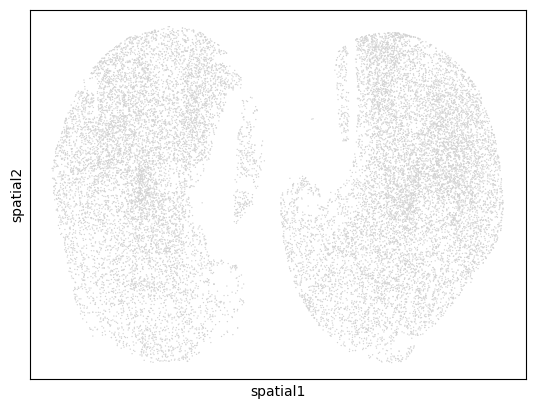

AnnData object with n_obs × n_vars = 32903 × 38606
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'sample', 'has_spatial'
    var: 'feature_types', 'genome', 'gene_symbol'
    obsm: 'spatial'
    layers: 'counts'

In [300]:
# Add spatila data
    # ATTENTION: adata.obs.dbscan_clusters == 1
adata.obs["has_spatial"] = (~adata.obs.x.isna()) & (~adata.obs.y.isna()) & (adata.obs.dbscan_clusters == 1)

# Add spaitla bsm
    # Create spatial matrix with NaN by default
spatial_coords = np.full((adata.n_obs, 2), np.nan)
    # For cells with has_spatial == True, add their real coordinates
mask = adata.obs['has_spatial']
spatial_coords[mask] = adata.obs.loc[mask, ['x', 'y']].values
    # Assign to obsm
adata.obsm['spatial'] = spatial_coords

# Plot
sc.pl.embedding(adata, basis="spatial")#, color="nCount_RNA")

display(adata)

# 4. Save

In [301]:
adata.write(f"{BASE_PATH}/{DISEASE_TYPE}/{SAMPLE_ID}/{BCL}/{LIBRARY}/adata/raw_adata.h5ad")

# ---